# Analyze One-At-A-Time Ensembles

In [24]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib

import fates_calibration_library.analysis_functions as analysis
import fates_calibration_library.oaat_functions as oaat
import fates_calibration_library.plotting_functions as plotting
import fates_calibration_library.utils as utils
import fates_calibration_library.clm_functions as clm
from fates_calibration_library.ilamb_functions import get_model_da

In [4]:
import importlib

## Set Up
File locations and ensemble information

In [18]:
# parameter directory
param_dir = '/glade/work/afoster/FATES_calibration/parameter_files'

# history output directory
hist_dir = '/glade/work/afoster/FATES_calibration/history_files/compiled_files'

ensemble_dict = {
    'fates': {
        'param_list': os.path.join(param_dir, "param_list_sci.1.85.1_api.40.0.0.xls"),
        'key': os.path.join(param_dir, 'fates_oaat', 'fates_oaat_key.csv'),
        'name': 'fates_oaat',
        'default': 0,
        'oaat_dir': os.path.join(param_dir, 'fates_oaat'),
        'param_prefix': 'FATES_OAAT_',
        'default_param': xr.open_dataset(os.path.join(param_dir,
                                                      'fates_params_default_sci.1.81.1_api.38.0.0_crops_vai.nc'))
    },
    'fates_clmpars': {
        'param_list': os.path.join(param_dir, 'CLM5_Parameter_List.csv'),
        'key': os.path.join(param_dir, 'clm6sp_oaat_key.csv'),
        'name': 'fates_oaat_clmpars',
        'default': 0,
        'oaat_dir': os.path.join(param_dir, 'clm_oaat'),
        'param_prefix': 'CLM6SPoaat',
        'default_param': xr.open_dataset('/glade/campaign/cesm/cesmdata/inputdata/lnd/clm2/paramdata/ctsm60_params.c241017.nc'),
        'nlmods_file': pd.read_csv(os.path.join(param_dir, 'clm6sp_nlmods.csv'))
    },
    'clm_btran': {
        'param_list': os.path.join(param_dir, 'CLM5_Parameter_List.csv'),
        'key': os.path.join(param_dir, 'clm6sp_oaat_key.csv'),
        'name': 'clm_oaat',
        'default': 0,
        'oaat_dir': os.path.join(param_dir, 'clm_oaat'),
        'param_prefix': 'CLM6SPoaat',
        'default_param': xr.open_dataset('/glade/campaign/cesm/cesmdata/inputdata/lnd/clm2/paramdata/ctsm60_params.c241017.nc'),
        'nlmods_file': pd.read_csv(os.path.join(param_dir, 'clm6sp_nlmods.csv'))
    }
}
fates = ensemble_dict['fates']
fates_clm = ensemble_dict['fates_clmpars']
clm_btran = ensemble_dict['clm_btran']

# config file with variable information in it
var_config = '/glade/work/afoster/FATES_calibration/fates_calibration_library/configs/model_conversion.yaml'
var_dict = utils.get_config_file(var_config)

# output directory for figures
fig_dir = '/glade/work/afoster/FATES_calibration/figures/oaat_figs'

# variables to look at 
variables = ['GPP', 'EFLX_LH_TOT', 'FSH', 'EF', 'ASA', 'SOILWATER_10CM',
             'BTRANMN']

obs_config_file = '/glade/work/afoster/FATES_calibration/fates_calibration_library/configs/ilamb_conversion.yaml'
obs_config = utils.get_config_file(obs_config_file)

fates_clm_config = '/glade/work/afoster/FATES_calibration/fates_calibration_library/configs/fates_clm_index.yaml'
fates_to_clm = utils.get_config_file(fates_clm_config)

clm_pft_config = '/glade/work/afoster/FATES_calibration/fates_calibration_library/configs/clm_index_to_name.yaml'
clm_pfts = utils.get_config_file(clm_pft_config)

ilamb_obs_file = '/glade/work/afoster/FATES_calibration/observations/all_ILAMB_obs.nc'
ilamb_dat = xr.open_dataset(ilamb_obs_file)

## Read in parameter information

In [6]:
# oaat key
fates_key = pd.read_csv(fates['key'], index_col=0)

fates_param_dat = oaat.get_fates_param_dat(fates['param_list'], fates_key)

clm_param_dat = oaat.get_clm_param_dat(fates_clm['param_list'])

all_params = pd.concat([clm_param_dat.to_pandas().reset_index().drop(columns=['type', 'ensemble']).drop_duplicates(), 
                        fates_param_dat.to_pandas().reset_index().drop(columns=['type', 'ensemble']).drop_duplicates()])

## Analysis

### Global annual means

In [31]:
# FATES SP ensemble with FATES parameters
fates_glob = oaat.get_area_means_diffs(os.path.join(hist_dir, f"{fates['name']}_area_means.nc"),
                                       fates_param_dat, variables, fates['default'])
fates_mean = fates_glob.sel(summation_var='mean')
fates_iav = fates_glob.sel(summation_var='iav')

fates_biome = oaat.get_area_means_diffs(os.path.join(hist_dir, f"{fates['name']}_biome_area_means.nc"),
                                       fates_param_dat, variables, fates['default'])

In [32]:
# FATES SP ensemble with CLM parameters
fatesclm_glob = oaat.get_area_means_diffs(os.path.join(hist_dir, f"{fates_clm['name']}_area_means.nc"),
                                       clm_param_dat, variables, fates_clm['default'])
fatesclm_mean = fatesclm_glob.sel(summation_var='mean')
fatesclm_iav = fatesclm_glob.sel(summation_var='iav')

fatesclm_biome = oaat.get_area_means_diffs(os.path.join(hist_dir, f"{fates_clm['name']}_biome_area_means.nc"),
                                       clm_param_dat, variables, fates_clm['default'])

In [33]:
# combine FATES ensembles into one
fates_glob_combo = oaat.get_combined(fates_glob, fatesclm_glob, 'fates parameters', 'clm parameters')
fates_combo_mean = fates_glob_combo.sel(summation_var='mean')

fates_biome_combo = oaat.get_combined(fates_biome, fatesclm_biome, 'fates parameters', 'clm parameters')

In [34]:
# CLM SP ensemble with CLM parameters (BTRAN)
clmbtran_glob = oaat.get_area_means_diffs(os.path.join(hist_dir, f"{clm_btran['name']}_area_means.nc"),
                                       clm_param_dat, variables, clm_btran['default'])
clmbtran_glob['sim_source'] = 'clm parameters'
clmbtran_mean = clmbtran_glob.sel(summation_var='mean')
clmbtran_iav = clmbtran_glob.sel(summation_var='iav')

clm_biome = oaat.get_area_means_diffs(os.path.join(hist_dir, f"{clm_btran['name']}_biome_area_means.nc"),
                                       clm_param_dat, variables, clm_btran['default'])

In [35]:
clm_ensemble = clmbtran_mean.where(clmbtran_mean.sum_diff > 0.0, drop=True)
clm_ensemble = clm_ensemble.to_pandas().reset_index().drop(columns=['ensemble'])
clm_ensemble['model'] = 'CLM'

fates_ensemble = fates_glob_combo.sel(summation_var='mean').where(fates_glob_combo.sum_diff > 0.0, drop=True)
fates_ensemble = fates_ensemble.to_pandas().reset_index().drop(columns=['ensemble'])
fates_ensemble['model'] = 'FATES'

In [36]:
clm_sd = clmbtran_iav.where(clmbtran_iav.sum_diff > 0.0, drop=True)
clm_sd = clm_sd.to_pandas().reset_index().drop(columns=['ensemble'])
clm_sd['model'] = 'CLM'

fates_sd = fates_glob_combo.sel(summation_var='iav').where(fates_glob_combo.sum_diff > 0.0, drop=True)
fates_sd = fates_sd.to_pandas().reset_index().drop(columns=['ensemble'])
fates_sd['model'] = 'FATES'

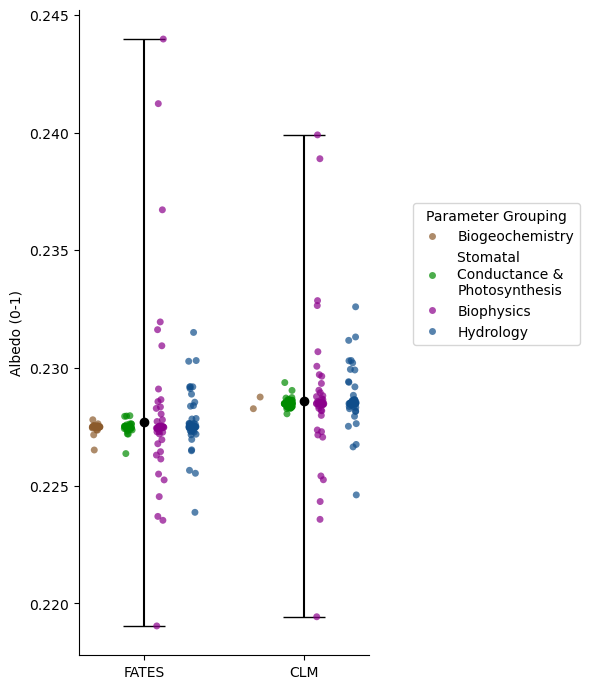

In [91]:
variable = 'ASA'
plotting.plot_ensemble_variance(fates_ensemble, clm_ensemble, 'FATES', 'CLM', variable,
                                var_dict[variable]['long_name'],
                               var_dict[variable]['global_units'])
# plt.savefig(os.path.join(fig_dir, f'{variable}_ensemble_variance.png'))

In [95]:
# find non-zero parameters for all simulations
nonzero_params = oaat.get_params(fates_glob, fatesclm_glob, clmbtran_glob)
clm_params = np.unique(np.append(nonzero_params['fates_clm'], nonzero_params['clm_parameters']))

fates_nonzero = fates_param_dat.where(fates_param_dat.parameter_name.isin(nonzero_params['fates_only']), drop=True).to_pandas()
fates_nonzero['type'] = 'FATES'

clmfates_nonzero = clm_param_dat.where(clm_param_dat.parameter_name.isin(nonzero_params['fates_clm']), drop=True).to_pandas()
clmfates_nonzero['type'] = 'CLM'

clm_nonzero = clm_param_dat.where(clm_param_dat.parameter_name.isin(nonzero_params['clm_parameters']), drop=True).to_pandas()
clm_nonzero['type'] = 'CLM'

fates_oaat_params = pd.concat([fates_nonzero, clmfates_nonzero])

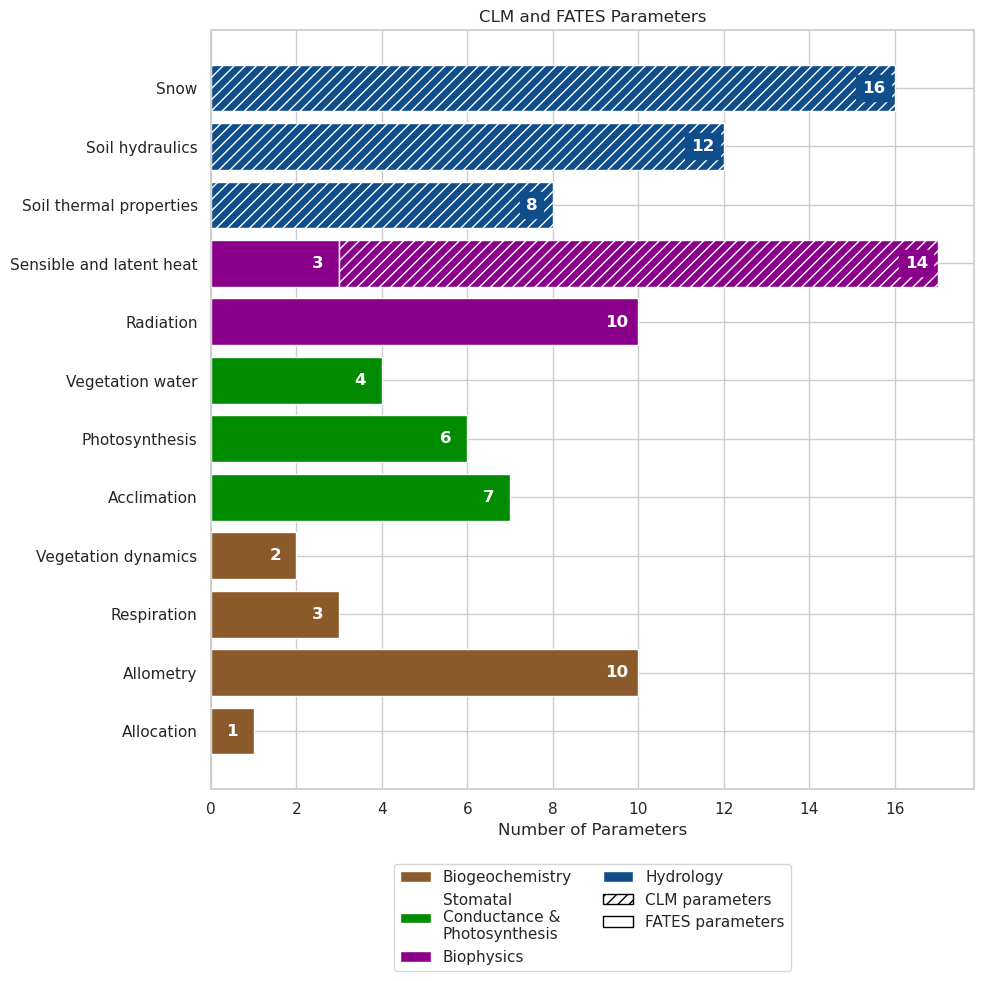

In [96]:
plotting.plot_oaat_params(fates_oaat_params.drop_duplicates(), 'CLM and FATES')
plt.savefig(os.path.join(fig_dir, 'fates_parameters.png'))

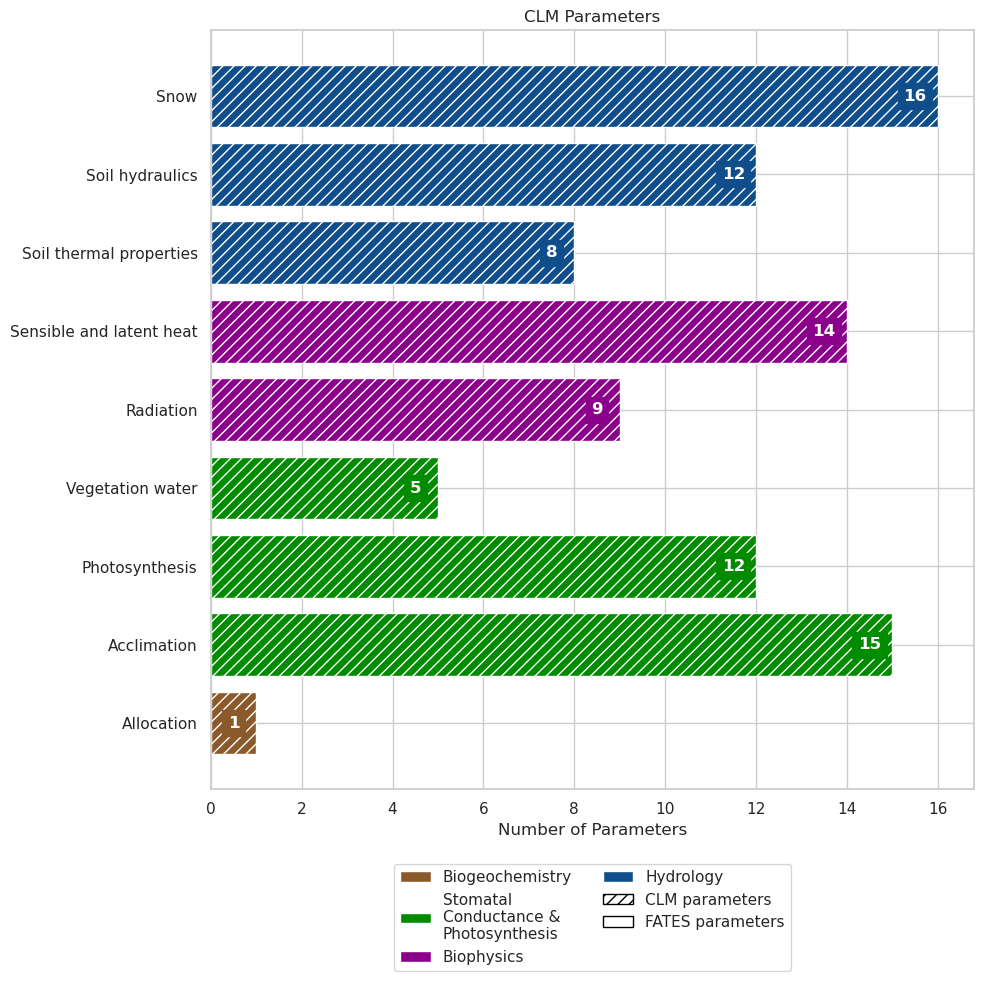

In [97]:
plotting.plot_oaat_params(clm_nonzero.drop_duplicates(), 'CLM')
plt.savefig(os.path.join(fig_dir, 'clm_oaat_parameters.png'))

In [98]:
clm_pars = np.unique(clmbtran_glob.where(clmbtran_glob.sum_diff > 0, drop=True).parameter_name.values)
fates_pars = np.unique(fates_glob_combo.where(fates_glob_combo.sum_diff > 0, drop=True).parameter_name.values)

In [99]:
variables = ['GPP', 'EF', 'ASA', 'SOILWATER_10CM']
variances = {}
for variable in variables:
    variances[variable] = {}
    
    clm_var = oaat.get_param_variance(clm_pars, variable, clmbtran_glob, 0)
    variances[variable]['CLM'] = oaat.get_cumulative_variance(clm_var, clm_pars, 5)

    fates_var = oaat.get_param_variance(fates_pars, variable, fates_glob_combo, 0)
    variances[variable]['FATES'] = oaat.get_cumulative_variance(fates_var, fates_pars, 5)

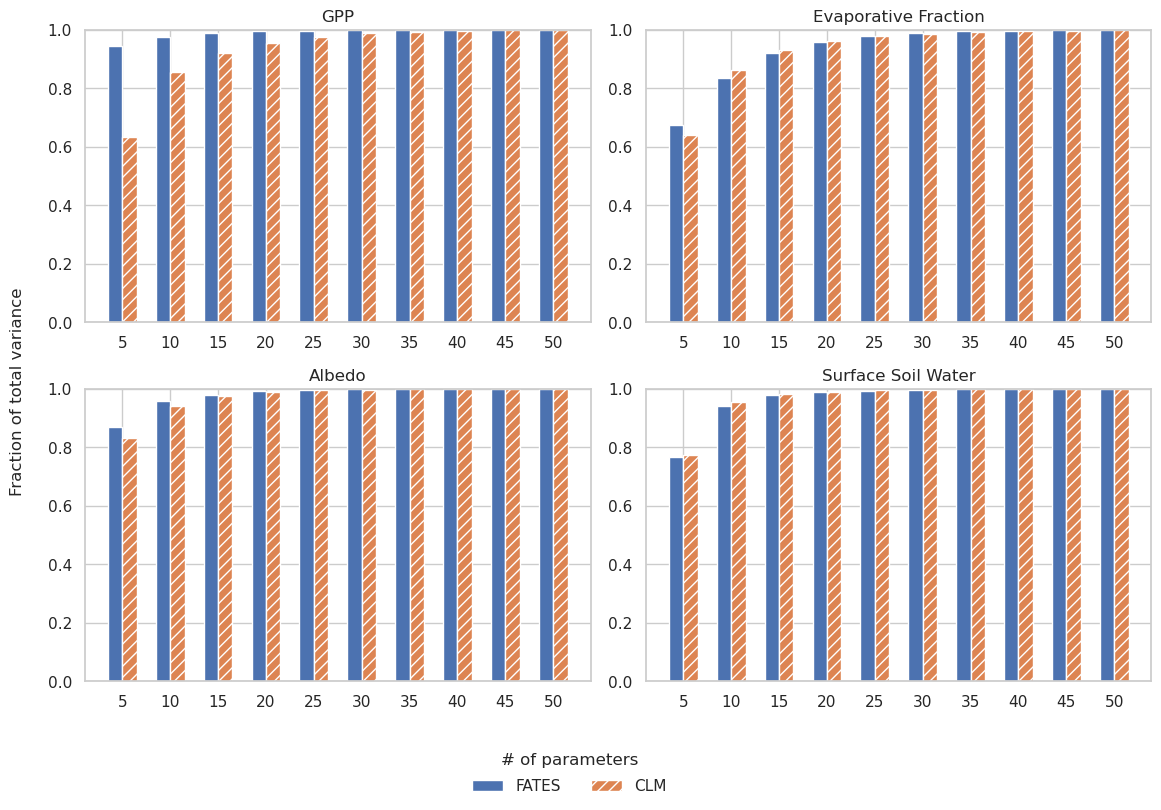

In [33]:
n_vars = len(variables)
ncols = 2
nrows = (n_vars + 1) // 2

fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 4 * nrows), sharex=False)

for idx, variable in enumerate(variables):
    row = idx // ncols
    col = idx % ncols
    ax = axs[row, col] if nrows > 1 else axs[col]

    width = 1.5
    fates_cumvar = variances[variable]['FATES']
    clm_cumvar = variances[variable]['CLM']
    ax.bar(fates_cumvar.nparams[:10] - width/2, fates_cumvar[:10], width=width, label='FATES')
    ax.bar(clm_cumvar.nparams[:10] + width/2, clm_cumvar[:10], width=width, label='CLM', hatch='///')

    ax.set_ylim([0, 1])
    ax.set_xticks(clm_cumvar.nparams[:10])
    ax.set_title(var_dict[variable]['long_name'])

fig.text(0.5, 0.04, '# of parameters', ha='center', va='center', fontsize=12)
fig.text(0.04, 0.5, 'Fraction of total variance', ha='center', va='center',
         rotation='vertical', fontsize=12)

handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.02),
    ncol=2,
    frameon=False
)
plt.tight_layout(rect=[0.05, 0.08, 1, 1])
plt.savefig(os.path.join(fig_dir, 'variance_explained.png'))

In [100]:
# global min max differences
fates_meandiffs = oaat.get_min_max_diff(fates_combo_mean)
fates_meandiffs['parameter'] = fates_meandiffs.index
fates_meandiffs['model'] = 'FATES'

clm_meandiffs = oaat.get_min_max_diff(clmbtran_mean)
clm_meandiffs['parameter'] = clm_meandiffs.index
clm_meandiffs['model'] = 'CLM'

In [36]:
exclude_list = np.append(nonzero_params['fates_clm'],
                         ['fates_leaf_vcmaxse', 'fates_leaf_vcmaxhd',
                          'fates_leaf_vcmaxha', 'fates_leaf_jmaxha',
                          'fates_leaf_jmaxse', 'fates_leaf_jmaxhd',
                          'fates_rad_stem_rhovis', 'fates_rad_leaf_rhovis',
                          'fates_rad_leaf_taunir', 'fates_rad_leaf_tauvis',
                          'fates_rad_stem_rhonir', 'fates_rad_stem_taunir',
                          'fates_rad_stem_tauvis', 'fates_rad_leaf_taunir',
                          'fates_rad_leaf_rhonir'])

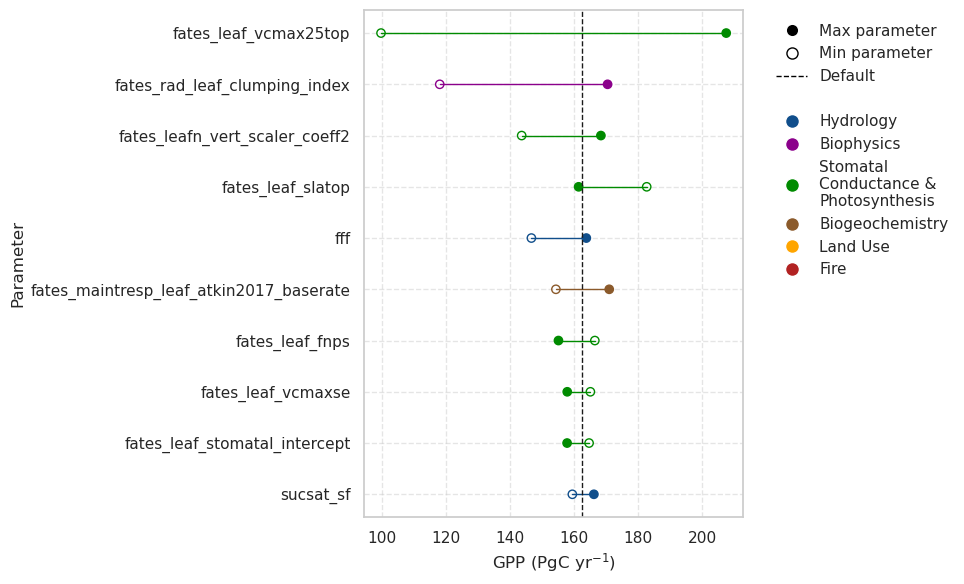

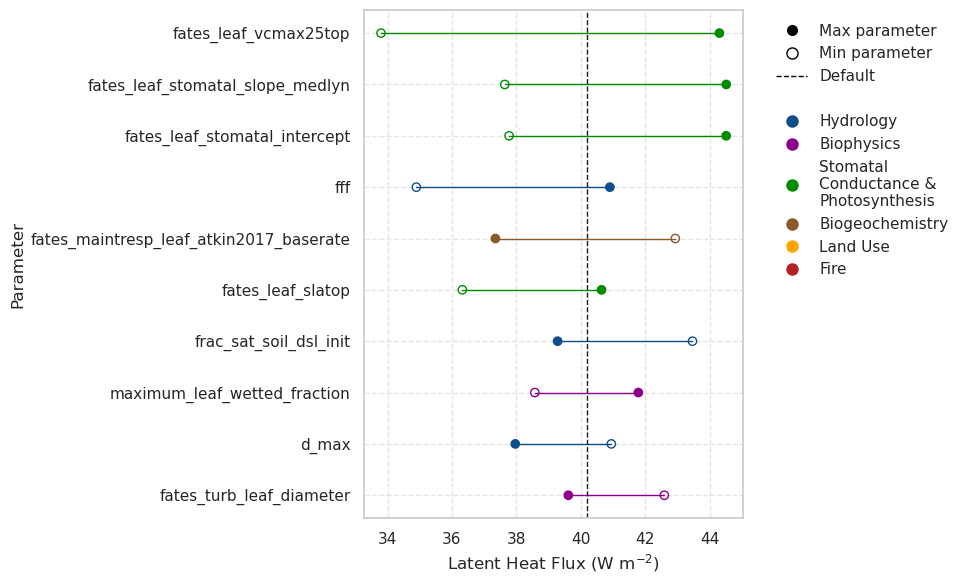

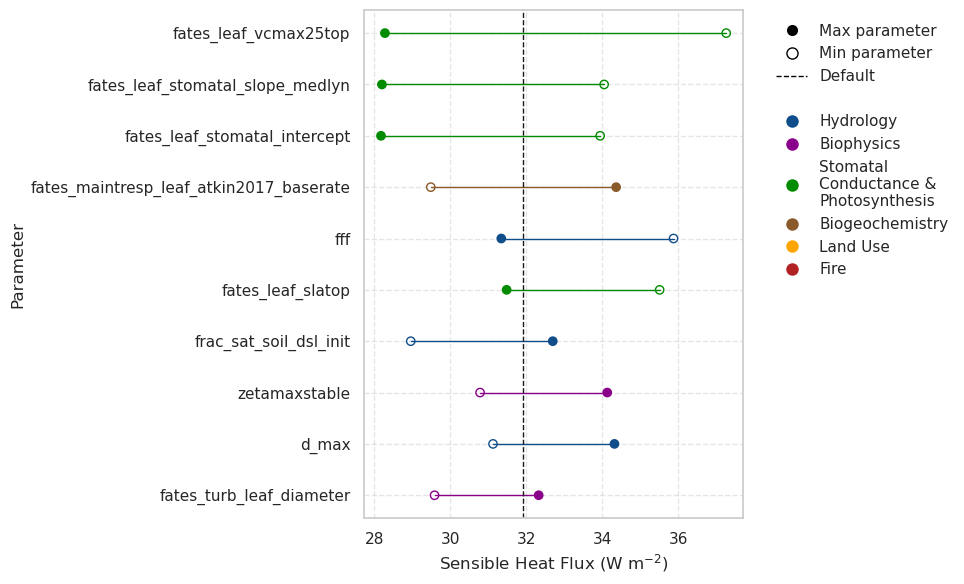

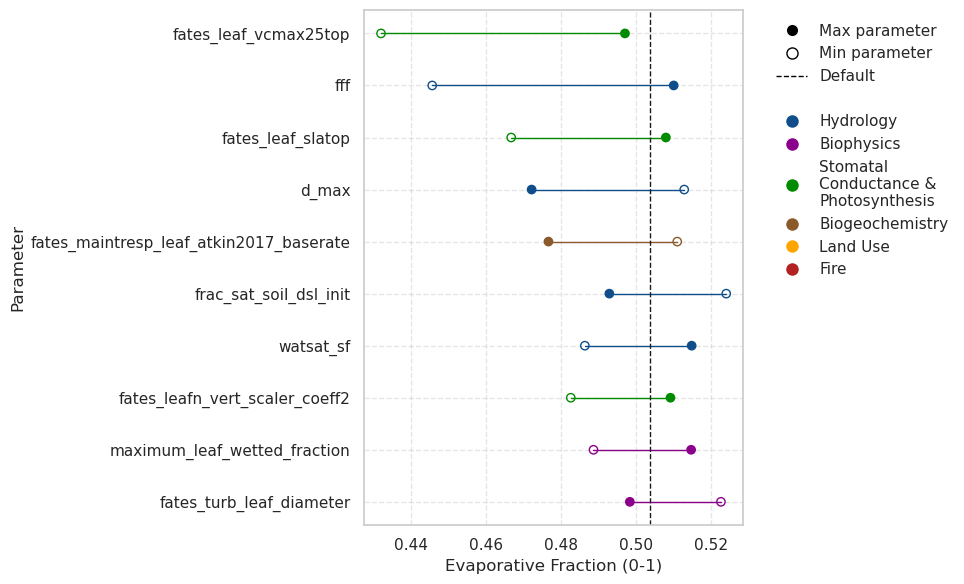

In [37]:
params = []
for variable in ['GPP', 'EFLX_LH_TOT', 'FSH', 'EF']:
    fates_top10 = oaat.get_top_n(fates_combo_mean, fates_meandiffs, variable,
                                 10)
    params.append(fates_top10.parameter_name.values)
    plotting.plot_top_n(fates_top10, fates_combo_mean.sel(ensemble=0), variable,
                        var_dict[variable]['long_name'],
                        var_dict[variable]['global_units'])
    plt.savefig(os.path.join(fig_dir, f'{variable}_top10_FATES.png'))

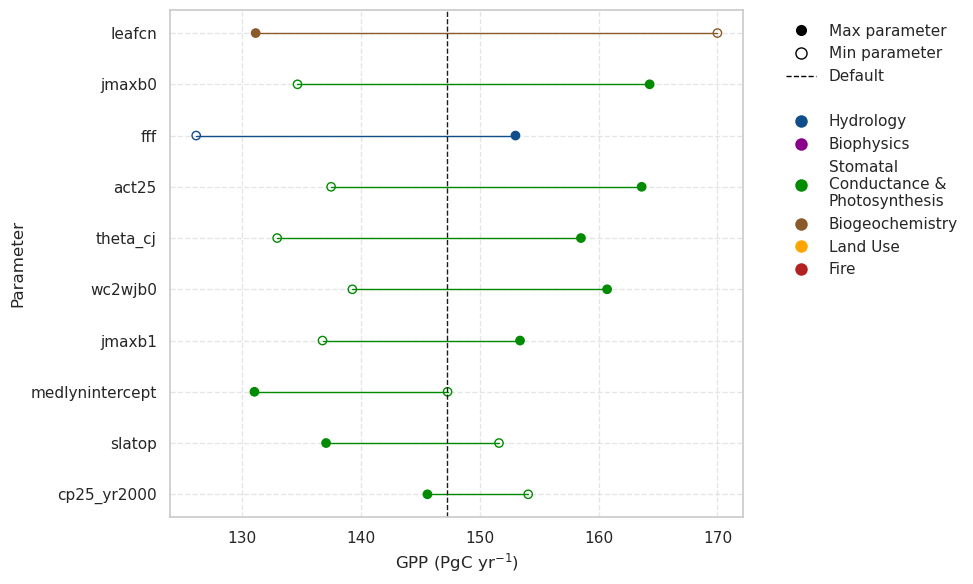

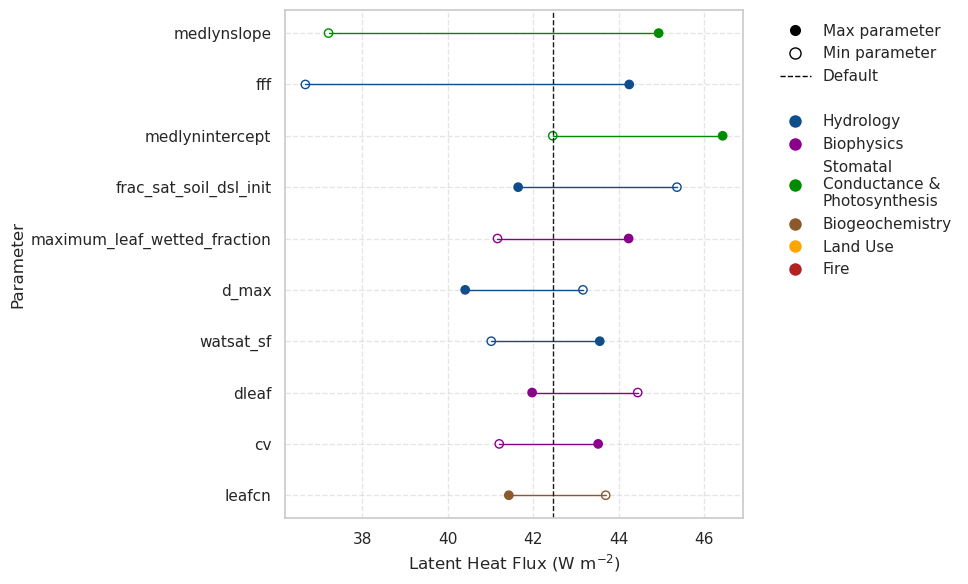

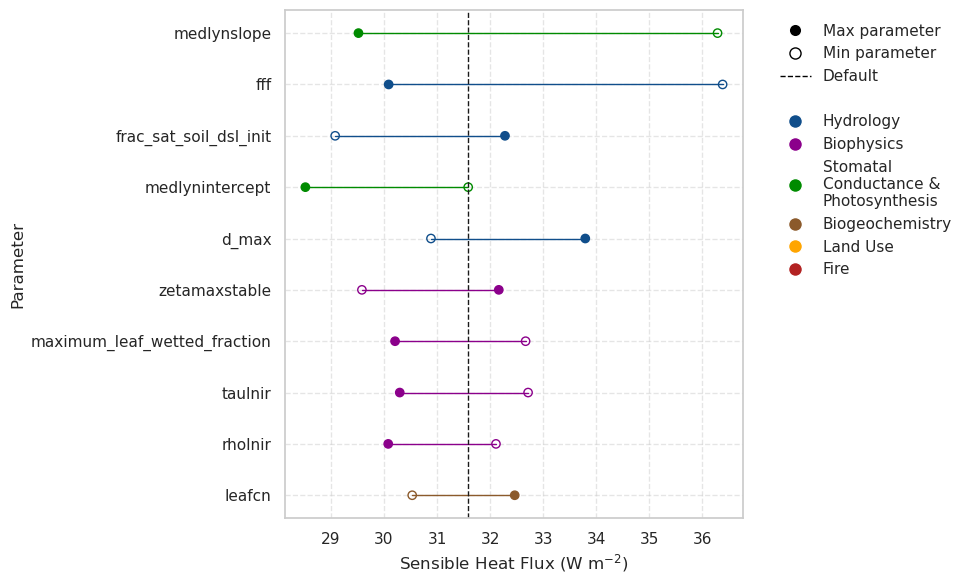

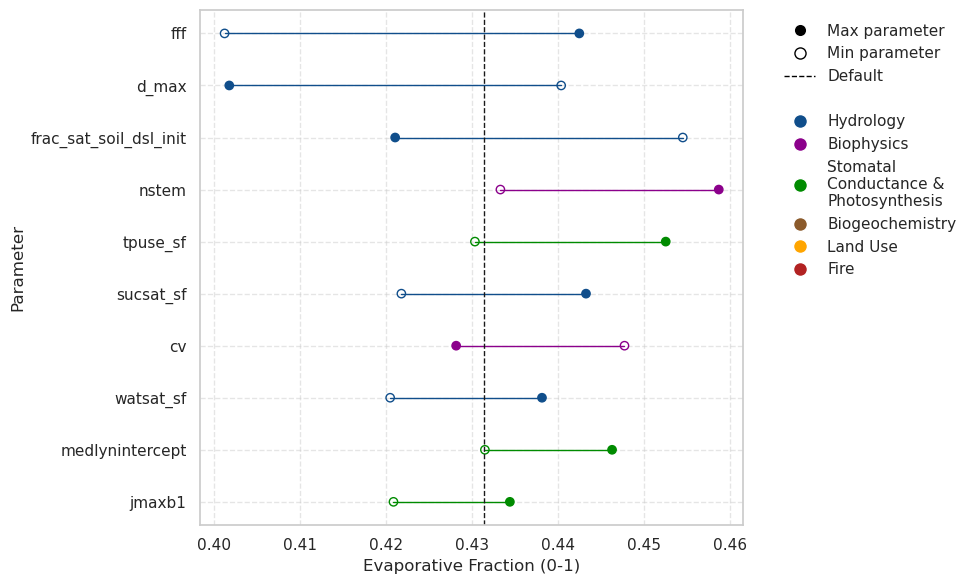

In [38]:
for variable in ['GPP', 'EFLX_LH_TOT', 'FSH', 'EF']:
    clm_top10 = oaat.get_top_n(clmbtran_mean, clm_meandiffs, variable, 10)
    plotting.plot_top_n(clm_top10, clmbtran_mean.sel(ensemble=0), variable,
                    var_dict[variable]['long_name'],
                    var_dict[variable]['global_units'])
    plt.savefig(os.path.join(fig_dir, f'{variable}_top10_CLM.png'))

In [39]:
biomes = fates_biome.biome.values
biome_diffs = []
for biome in biomes:
    df = oaat.get_min_max_diff(fates_biome.sel(summation_var='mean').sel(biome=biome))
    df['biome'] = biome
    biome_diffs.append(df)
biome_df = pd.concat(biome_diffs)

In [40]:
variable = 'GPP'

top10s = []
for biome in biomes:
    fates_biome_mean = fates_biome.sel(summation_var='mean').sel(biome=biome)
    diff_df = biome_df[biome_df.biome == biome]
    top10 = oaat.get_top_n(fates_biome_mean, diff_df, variable, 10)
    top10['biome'] = biome
    top10s.append(top10)
all_top_10 = pd.concat(top10s)

In [110]:
def get_all_vardiffs(variables, clmbtran_mean, fatesclm_mean, fates_mean,
                     nonzero_params, reldiff=False):
    
    clm_diffs = oaat.get_vardiff(clmbtran_mean, clmbtran_mean.sel(ensemble=0),
                                variables, nonzero_params['clm_parameters'],
                                reldiff=reldiff)
    clm_diffs['model'] = 'CLM'
    clm_diffs['parameter'] = clm_diffs.index
    
    fatesclm_diffs = oaat.get_vardiff(fatesclm_mean, fatesclm_mean.sel(ensemble=0),
                                     variables, nonzero_params['fates_clm'],
                                     reldiff=reldiff)
    fatesclm_diffs['model'] = 'FATES'
    fatesclm_diffs['parameter'] = fatesclm_diffs.index

    fates_diffs = oaat.get_vardiff(fates_mean, fates_mean.sel(ensemble=0),
                                         variables, nonzero_params['fates_only'],
                                         reldiff=reldiff)
    fates_diffs['model'] = 'FATES'
    fates_diffs['parameter'] = fates_diffs.index

    clm_sub = clm_diffs[clm_diffs.index.isin(fatesclm_diffs.parameter)]
    fates_clm_diff = pd.concat([clm_sub, fatesclm_diffs])
    fates_diffs = pd.concat([fatesclm_diffs, fates_diffs])

    return clm_diffs, fates_diffs, fates_clm_diff

In [115]:
variables = ['GPP', 'EFLX_LH_TOT', 'EF', 'ASA', 'FSH', 'SOILWATER_10CM',
             'BTRANMN', 'QVEGT', 'QVEGE', 'QSOIL', 'QRUNOFF']

clm_diffs, fates_diffs, fatesclm_diffs = get_all_vardiffs(variables, clmbtran_mean, fatesclm_mean, fates_mean,
                     nonzero_params, reldiff=False)

clm_reldiffs, fates_reldiffs, fatesclm_reldiffs = get_all_vardiffs(variables, clmbtran_mean, fatesclm_mean, fates_mean,
                     nonzero_params, reldiff=True)

In [143]:
def plot_var_diff(df, variable, tol, long_name, units=None, param_sub=None):

    if param_sub is not None:
        df = df[df.index.isin(param_sub)]

    if units is None:
        units = "%"
        type = "Percent"
    else:
        type = "Absolute"

    below_tol = df.groupby('parameter')[variable].apply(lambda g: (g <= tol).all().all())
    params_to_keep = below_tol[~below_tol].index
    df_filtered = df[df['parameter'].isin(params_to_keep)]
    
    df_filtered = df_filtered.sort_values(by=variable, ascending=False)

    plt.figure(figsize=(9, 10))
    sns.barplot(data=df_filtered, x=variable, y='parameter', hue='model')
    plt.xlabel(f"{type} Difference in {long_name} ({units})")
    plt.ylabel('Parameter')
    plt.legend(loc='lower right')
    plt.tight_layout()

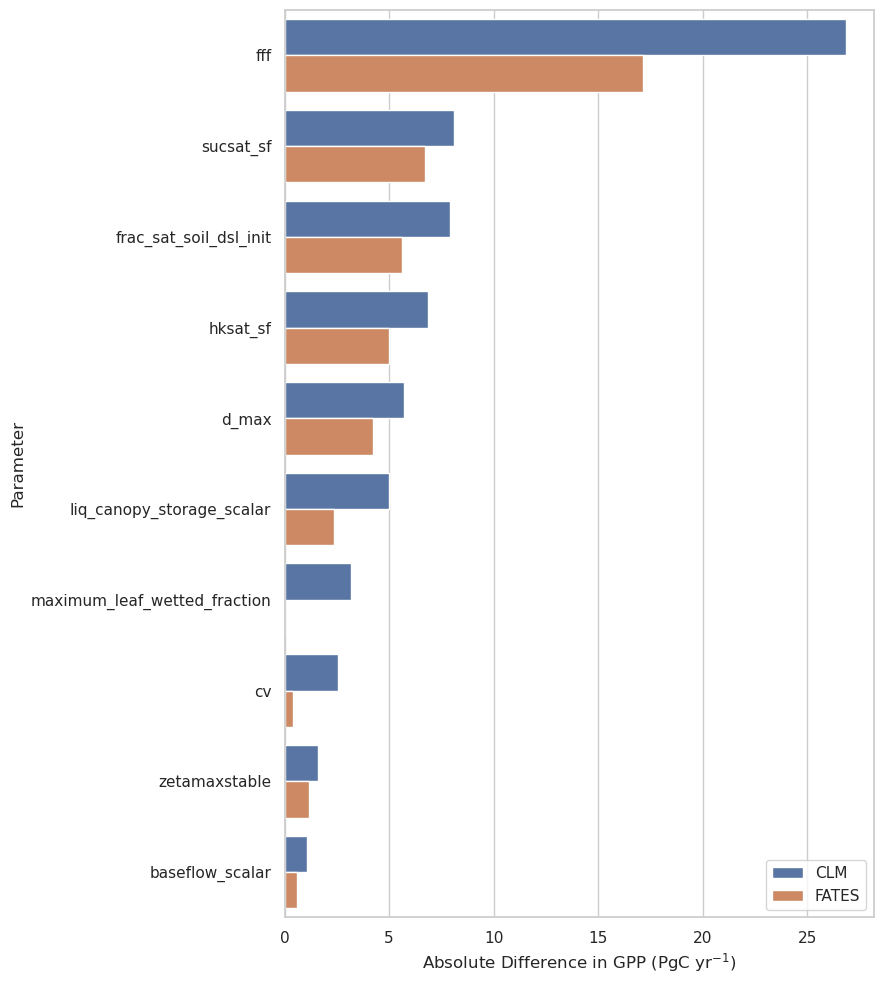

In [148]:
variable = 'GPP'
type = 'abs'
if type == 'rel':
    plot_var_diff(fatesclm_reldiffs, variable, 1, var_dict[variable]['long_name'])
else:
    plot_var_diff(fatesclm_diffs, variable, 1, var_dict[variable]['long_name'],
             var_dict[variable]['global_units'])
# plt.savefig(os.path.join(fig_dir, f'{variable}_FATES_CLM_compare.png'))

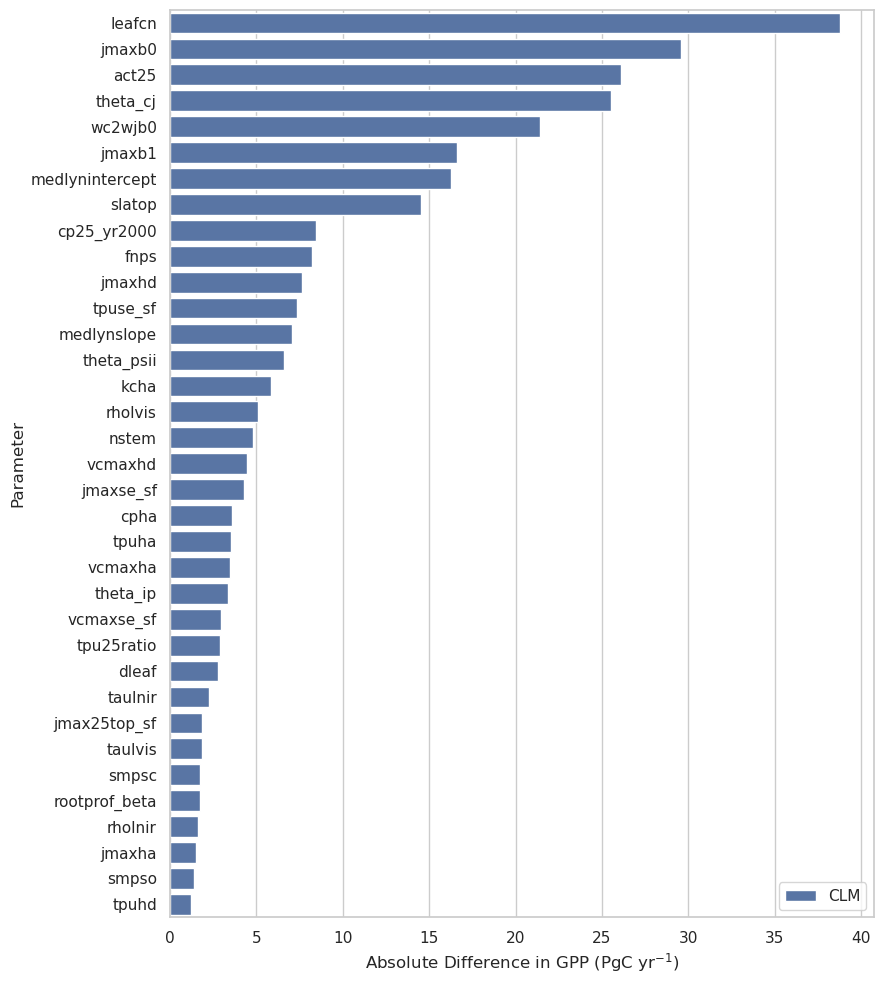

In [151]:
variable = 'GPP'
type = 'abs'


if type == 'rel':
    plot_var_diff(clm_reldiffs, variable, 1, var_dict[variable]['long_name'],
                  param_sub=nonzero_params['clm_only'])
else:
    plot_var_diff(clm_diffs, variable, 1, var_dict[variable]['long_name'],
             units=var_dict[variable]['global_units'],
                 param_sub=nonzero_params['clm_only'])

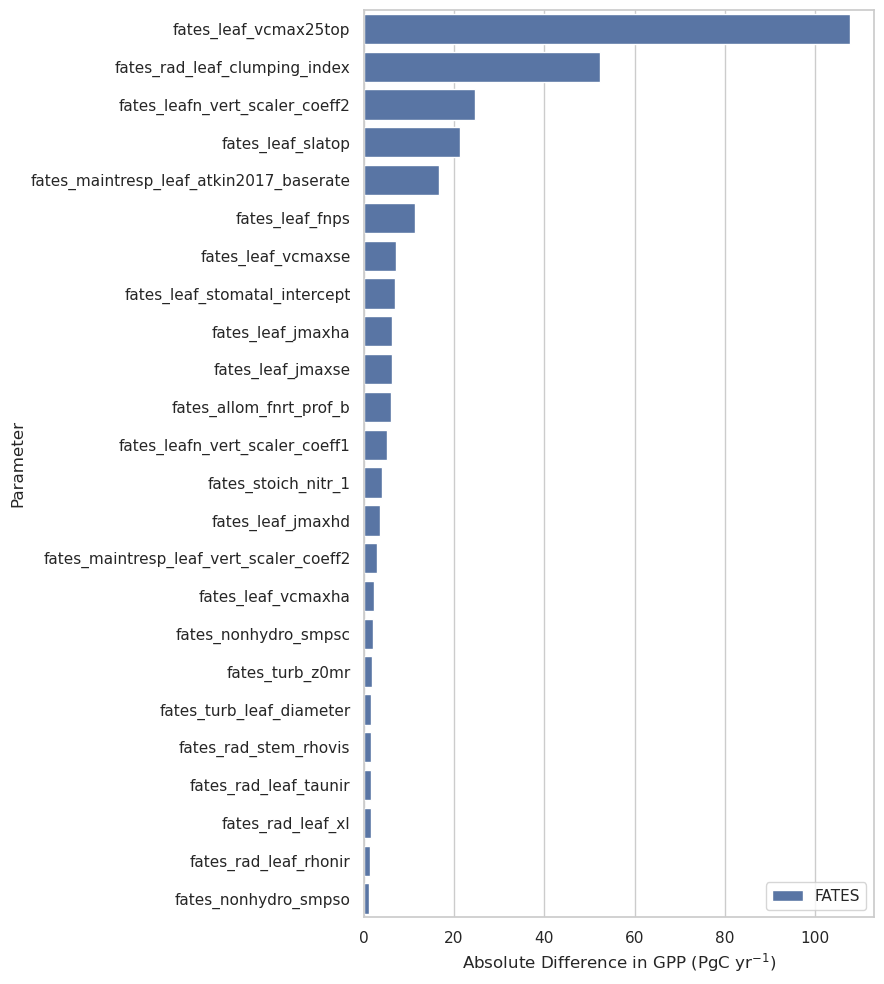

In [152]:
variable = 'GPP'
type = 'abs'

if type == 'rel':
    plot_var_diff(fates_reldiffs, variable, 1, var_dict[variable]['long_name'],
                  param_sub=nonzero_params['fates_only'])
else:
    plot_var_diff(fates_diffs, variable, 1, var_dict[variable]['long_name'],
             units=var_dict[variable]['global_units'],
                 param_sub=nonzero_params['fates_only'])

### Climatology

In [166]:
clim_fates = xr.open_dataset(os.path.join(hist_dir, f"{fates['name']}_climatology.nc"))
clim_fates_ens = clim_fates.where(clim_fates.ensemble > fates['default'], drop=True)
clim_fates_ens = xr.merge([clim_fates_ens, fates_param_dat])

clim_fates_clmpars = xr.open_dataset(os.path.join(hist_dir, f"{fates_clm['name']}_climatology.nc"))
clim_fates_clmpars_ens = clim_fates_clmpars.where(clim_fates_clmpars.ensemble > fates_clm['default'], drop=True)
clim_fates_clmpars_ens = xr.merge([clim_fates_clmpars_ens, clm_param_dat])

clim_clm = xr.open_dataset(os.path.join(hist_dir, f"{clm_btran['name']}_climatology.nc"))
clim_clm_ens = clim_clm.where(clim_clm.ensemble > clm_btran['default'], drop=True)
clim_clm_ens = xr.merge([clim_clm_ens, clm_param_dat])

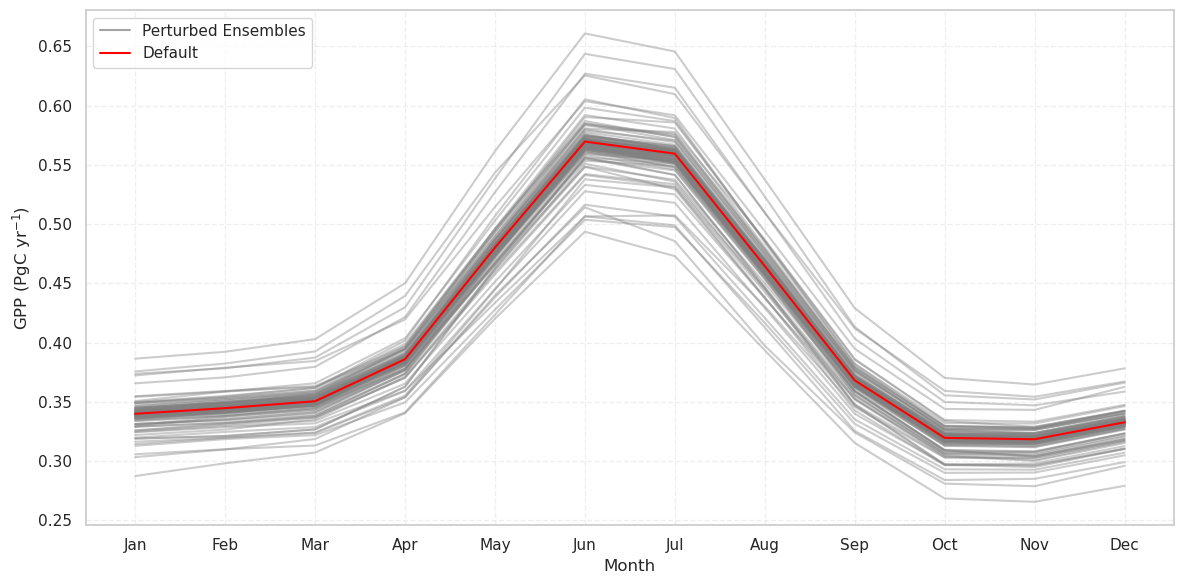

In [167]:
variable = 'GPP'
plotting.plot_oaat_climatology(clim_clm_ens, clim_clm.isel(ensemble=0),
                               variable, var_dict[variable]['long_name'],
                               var_dict[variable]['global_units'], None)

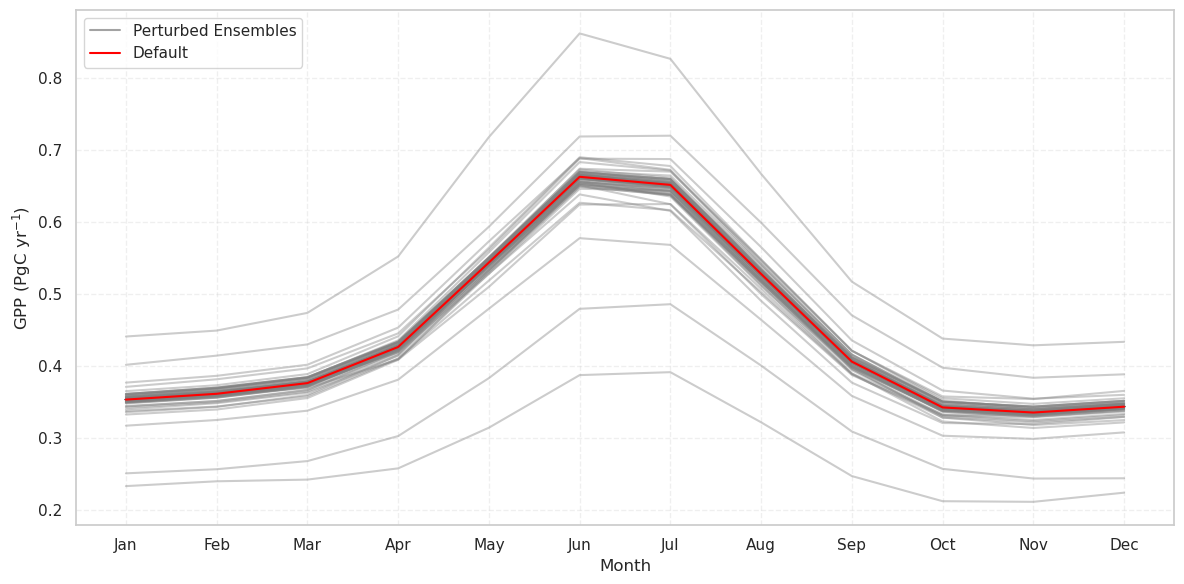

In [168]:
variable = 'GPP'
plotting.plot_oaat_climatology(clim_fates_ens, clim_fates.isel(ensemble=0),
                               variable, var_dict[variable]['long_name'],
                               var_dict[variable]['global_units'], None)

### Zonal Means

In [169]:
zonal_fates = xr.open_dataset(os.path.join(hist_dir, f"{fates['name']}_zonal_means.nc"))
zonal_fates_ens = zonal_fates.where(zonal_fates.ensemble > fates['default'], drop=True)
zonal_fates_ens = xr.merge([zonal_fates_ens, fates_param_dat])

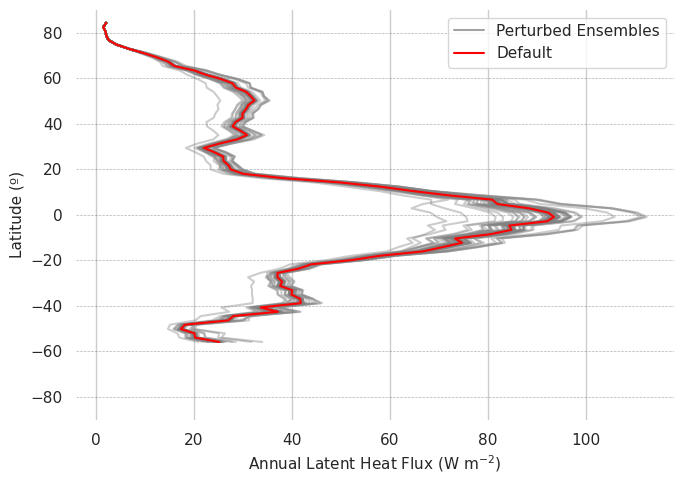

In [170]:
variable = 'EFLX_LH_TOT'
plotting.plot_oaat_zonal(zonal_fates_ens, zonal_fates.sel(ensemble=0), variable,
                     var_dict[variable]['long_name'], var_dict[variable]['annual_units'])

### Maps

In [158]:
# create a global land frac and area grid
land_frac_ds = os.path.join("/glade/derecho/scratch/afoster/archive",
                            "ctsm60SP_bigleaf_fullgrid/lnd/hist",
                            "ctsm60SP_bigleaf_fullgrid.clm2.h0.0001-02-01-00000.nc")
target_grid = clm.create_target_grid(land_frac_ds, 'FSR')
ds_frac = xr.Dataset({'landfrac': target_grid.landfrac,
                'landarea': target_grid.land_area})

In [159]:
fates_maps = xr.open_dataset(os.path.join(hist_dir, f"{fates['name']}_annual_maps.nc"))
fates_maps_ens = fates_maps.where(fates_maps.ensemble > fates['default'], drop=True)
fates_maps_ens = xr.merge([fates_maps_ens, fates_param_dat])

In [160]:
fates_clm_maps = xr.open_dataset(os.path.join(hist_dir, f"{fates_clm['name']}_annual_maps.nc"))
fates_clm_maps_ens = fates_clm_maps.where(fates_clm_maps.ensemble > fates_clm['default'], drop=True)
fates_clm_maps_ens = xr.merge([fates_clm_maps_ens, clm_param_dat])

In [161]:
clm_maps = xr.open_dataset(os.path.join(hist_dir, f"{clm_btran['name']}_annual_maps.nc"))
clm_maps_ens = clm_maps.where(clm_maps.ensemble > clm_btran['default'], drop=True)
clm_maps_ens = xr.merge([clm_maps_ens, clm_param_dat])

In [163]:
parameter = 'fff'

if parameter in nonzero_params['fates_only']:
    dat_fates = fates_maps_ens.where(fates_maps_ens.parameter_name == parameter, drop=True)
    dat_clm = None
elif parameter in nonzero_params['fates_clm']:
    dat_fates = fates_clm_maps_ens.where(fates_clm_maps_ens.parameter_name == parameter, drop=True)
    dat_clm = clm_maps_ens.where(clm_maps_ens.parameter_name == parameter, drop=True)
else:
    dat_clm = clm_maps_ens.where(clm_maps_ens.parameter_name == parameter, drop=True)
    dat_fates = None

In [ ]:
variable = 'GPP'

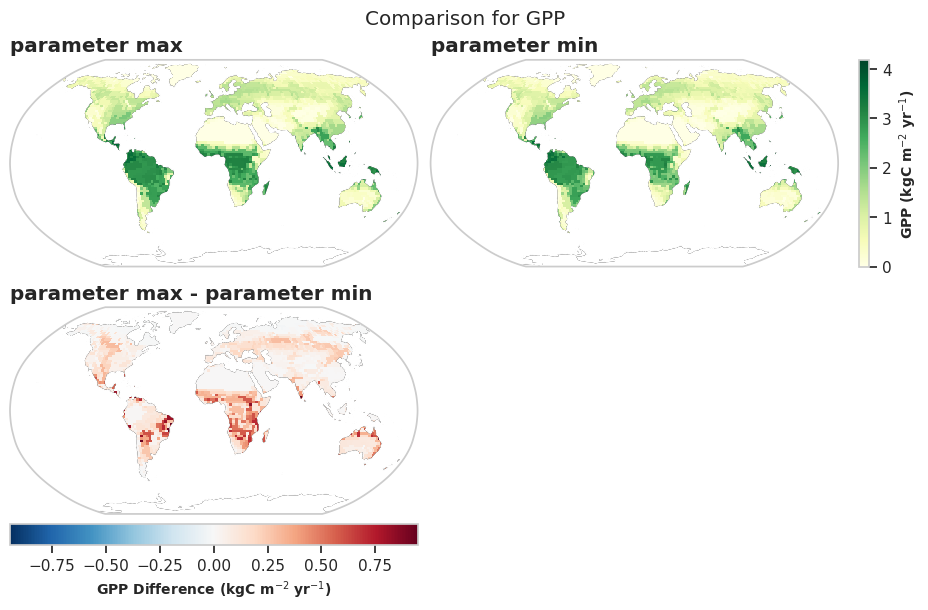

In [164]:
if dat_fates is not None:
    plotting.plot_two_model_diff(dat_fates[variable].isel(ensemble=0),
                                 dat_fates[variable].isel(ensemble=1),
                                 'parameter min', 'parameter max', var_dict[variable]['long_name'],
                                 var_dict[variable]['annual_units'], var_dict[variable]['cmap'])

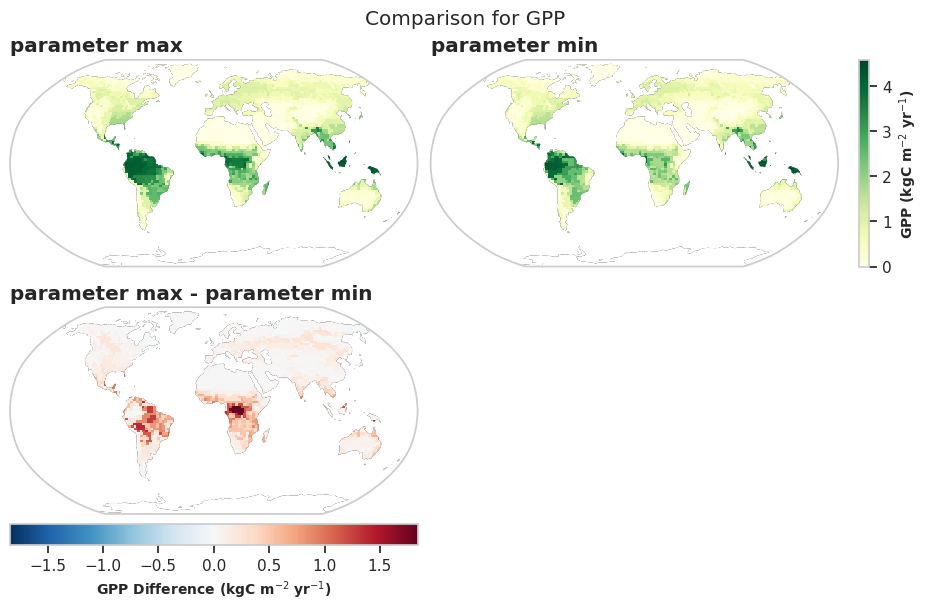

In [165]:
if dat_clm is not None:
    plotting.plot_two_model_diff(dat_clm[variable].isel(ensemble=0),
                                 dat_clm[variable].isel(ensemble=1),
                                 'parameter min', 'parameter max', var_dict[variable]['long_name'],
                                 var_dict[variable]['annual_units'], var_dict[variable]['cmap'])